# 💳 **Clasificador inteligente de gastos**

<div align="center">

## Desarrollo de un modelo de Machine Learning para categorizar transacciones financieras

</div>

<br>

**Proyecto:** FinanceAI

**Equipo:** LATAM Team 80

**Hackathon:** ONE – Proyectos G9 | Alura + Oracle

**Área:** Ciencia de Datos y Machine Learning

<br>

---

</div>

## 📌 Descripción

En este notebook se desarrolla un modelo de clasificación capaz de identificar automáticamente la categoría de un gasto a partir de la descripción de una transacción financiera.

La solución busca transformar textos como:

> “Pago mensual de Netflix”

en categorías financieras como:

> **Entretenimiento**

Este componente forma parte de **FinanceAI**, una solución orientada al análisis de hábitos financieros, la identificación de patrones de consumo y la generación de recomendaciones para mejorar la salud financiera de los usuarios.

## 🎯 Objetivo principal

Construir, evaluar y documentar un modelo de Machine Learning que clasifique automáticamente las transacciones financieras en categorías de gasto relevantes.

## 🔍 Alcance del notebook

A lo largo del análisis se realizarán las siguientes actividades:

* exploración y comprensión de los datos;
* limpieza y normalización de las descripciones;
* análisis de la distribución de categorías;
* transformación del texto en variables numéricas;
* entrenamiento de modelos de clasificación;
* evaluación y comparación de resultados;
* análisis de errores y predicciones;
* creación de una función para clasificar nuevas transacciones.

---

> **Nota:** El notebook está diseñado con un enfoque didáctico y reproducible, explicando no solo qué se hace, sino también por qué se toma cada decisión.

# 🗂️ Contenido

1. [Planteamiento del problema](#1-planteamiento-del-problema)
2. [Configuración](#2-configuración)
3. [Carga de datos](#3-carga-de-datos)
4. [Exploración de datos (EDA)](#4-exploración-de-datos-eda)
5. [Clasificador v1 — reglas con palabras clave](#5-clasificador-v1--reglas-con-palabras-clave)
6. [Modelo v2 — clasificador entrenado](#6-modelo-v2--clasificador-entrenado)
7. [Evaluación comparativa: reglas vs. modelo](#7-evaluación-comparativa-reglas-vs-modelo)
8. [Análisis de errores del modelo](#8-análisis-de-errores-del-modelo)
9. [Serialización — el modelo listo para la API](#9-serialización--el-modelo-listo-para-la-api)
10. [Conclusiones, limitaciones y próximos pasos](#10-conclusiones-limitaciones-y-próximos-pasos)

# 1. Planteamiento del problema

La tarea se aborda como un problema de **clasificación supervisada multiclase** sobre texto:

| Descripción de la transacción | Categoría esperada |
| ----------------------------- | ------------------ |
| Pago mensual de Netflix       | Entretenimiento y ocio |
| Compra en supermercado        | Alimentación       |
| Factura de energía            | Vivienda y servicios |
| Viaje en Uber                 | Transporte         |

* **Entrada:** la descripción de la transacción.
* **Salida:** una de las 10 categorías definidas por el equipo.
* **Evaluación:** accuracy y F1-score por categoría, con matriz de confusión, midiendo sobre transacciones que el modelo no vio durante el entrenamiento.

Se compararán dos enfoques: una **versión 1 por reglas de palabras clave** (línea base interpretable) y una **versión 2 con Machine Learning** entrenada sobre el dataset construido por el equipo.

# 2. Configuración

Fijamos una semilla para que los resultados sean reproducibles.

In [118]:
RANDOM_STATE = 42  # semilla fija: mismos resultados en cada ejecución

# 3. Carga de datos

El dataset fue construido por el equipo mediante simulación y curaduría manual, como permite el reto: 274 transacciones etiquetadas en 10 categorías, con montos en escala USD. Incluye tres estilos de descripción a propósito: texto manual, formato de extracto bancario y marcas locales de varios países — para reflejar datos reales.

In [119]:
import pandas as pd

url_1 = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-80-FinanceAI/feature/clasificador-gastos/dataset_gastos.csv"
df = pd.read_csv(url_1, encoding="utf-8-sig", parse_dates=["fecha"])

In [120]:
df.sample(5) # Visualizar 5 registros random

,fecha,descripcion,valor,categoria
206,2026-06-20,Crédito de consumo Falabella,74,obligaciones
179,2026-06-09,Renta departamento CDMX,350,vivienda
263,2026-07-08,Recarga celular prepago,5,vivienda
1,2026-04-01,Vestido para matrimonio,80,cuidado_personal
47,2026-04-17,Plomero arreglo cocina,30,vivienda


# 4. Exploración de datos (EDA)

Antes de modelar, verificamos la calidad del dataset: estructura, valores faltantes, duplicados, balance entre categorías y rango de fechas y montos.

In [121]:
print("Columnas del dataset:\n")
print(pd.DataFrame({"Columnas" :df.columns.values}))

Columnas del dataset:

      Columnas
0        fecha
1  descripcion
2        valor
3    categoria


In [122]:
print("Cantidad de registros del dataset:\n")
print(df.shape[0])

Cantidad de registros del dataset:

274


In [123]:
print("Tipos de datos presentes en cada columna del dataset:\n")
print(df.dtypes)

Tipos de datos presentes en cada columna del dataset:

fecha          datetime64[ns]
descripcion            object
valor                   int64
categoria              object
dtype: object


In [124]:
print("Cantidad de datos nulos en cada columna del dataset:\n")
print(df.isna().sum())

Cantidad de datos nulos en cada columna del dataset:

fecha          0
descripcion    0
valor          0
categoria      0
dtype: int64


In [125]:
print("Cantidad de registros duplicados en el dataset:\n")
print(df.duplicated().sum())

Cantidad de registros duplicados en el dataset:

0


## 4.1 Distribución por categoría

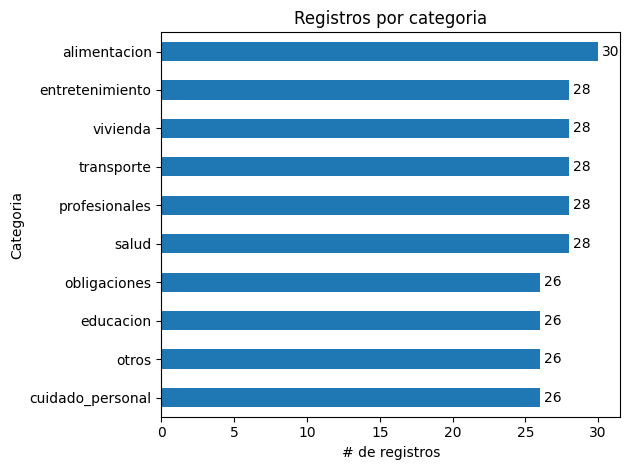

In [126]:
import matplotlib.pyplot as plt

conteo = df["categoria"].value_counts().sort_values() # Contabilizar la cantidad de registros asociados a cada categoria

ax =  conteo.plot(kind="barh", title="Registros por categoria")
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel("# de registros")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.show()


Las 10 categorías tienen entre 26 y 30 ejemplos. Un balance suficiente para entrenar y evaluar sin que ninguna clase domine.

## 4.2 Montos

Los montos no alimentan al clasificador (que solo lee la descripción), pero verificamos que sean coherentes.

In [127]:
print(df["valor"].describe())

count     274.000000
mean       59.916058
std       122.188665
min         1.000000
25%        10.000000
50%        24.000000
75%        59.500000
max      1050.000000
Name: valor, dtype: float64


Dado que no hay valores negativos, no se requiere hacer limpieza adicional en el campo de valores.

# 5. Clasificador v1 — reglas con palabras clave

Nuestra línea base es un clasificador interpretable: un diccionario donde cada categoría tiene sus palabras delatoras. Dos decisiones de diseño importan aquí:

- **El orden es la prioridad:** gana la primera categoría cuya palabra aparezca. Por eso `profesionales` se evalúa primero — el propósito le gana al artículo ("Almuerzo con cliente" es gasto profesional aunque diga almuerzo).
- **Emparejamiento por palabra completa** y texto normalizado (minúsculas, sin tildes), para que "gas" no se esconda dentro de "gasolina" y "Éxito" encuentre a "exito".

In [128]:
import json
import re
import unicodedata
import requests

url_2 = "https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team-80-FinanceAI/feature/clasificador-gastos/palabras-clave.json"

PALABRAS = requests.get(url_2).json()

def limpiar(texto):
    t = texto.lower()
    t = unicodedata.normalize("NFD", t)
    return "".join(c for c in t if unicodedata.category(c) != "Mn")

def clasificar_v1(descripcion):
    d = limpiar(descripcion)
    for categoria, palabras in PALABRAS.items():
        for p in palabras:
            if re.search(rf"\b{re.escape(p)}\b", d):
                return categoria
    return "otros"

clasificar_v1("Supermercado Éxito"), clasificar_v1("Almuerzo con cliente")

('alimentacion', 'profesionales')

## 5.1 Evaluación del clasificador v1

Evaluamos las reglas sobre las 274 transacciones usando las mismas métricas que luego aplicaremos al modelo entrenado, para compararlos de igual a igual:

| Métrica | Qué responde |
| --- | --- |
| **Accuracy** | ¿Qué proporción del total acierta? |
| **Precision** | Cuando nombra una categoría, ¿qué tan confiable es? |
| **Recall** | De las transacciones reales de una categoría, ¿cuántas identifica? |
| **F1-score** | El equilibrio entre precision y recall. |

Resultado general: 225 de 274 transacciones (82.1%)

                  precision    recall  f1-score   support

    alimentacion       0.94      0.53      0.68        30
cuidado_personal       1.00      0.85      0.92        26
       educacion       1.00      0.88      0.94        26
 entretenimiento       1.00      0.82      0.90        28
    obligaciones       0.92      0.92      0.92        26
           otros       0.37      0.92      0.53        26
   profesionales       0.89      0.86      0.87        28
           salud       0.96      0.79      0.86        28
      transporte       0.96      0.89      0.93        28
        vivienda       1.00      0.79      0.88        28

        accuracy                           0.82       274
       macro avg       0.90      0.83      0.84       274
    weighted avg       0.91      0.82      0.84       274



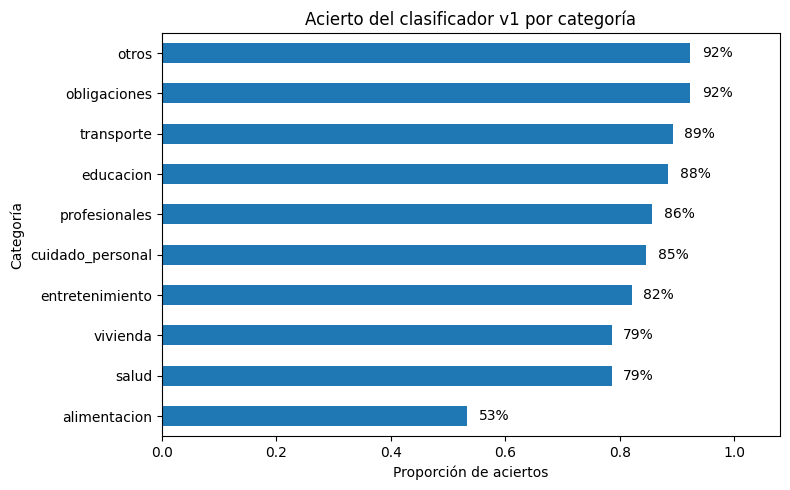

In [129]:
import sklearn
from sklearn.metrics import classification_report

df["pred_v1"] = df["descripcion"].apply(clasificar_v1)

aciertos = (df["pred_v1"] == df["categoria"]).sum()
total = len(df)
acc_v1 = aciertos / total
print(f"Resultado general: {aciertos} de {total} transacciones ({acc_v1:.1%})\n")

print(classification_report(df["categoria"], df["pred_v1"], zero_division=0))

acc_por_cat = (df["pred_v1"] == df["categoria"]).groupby(df["categoria"]).mean().sort_values()
ax = acc_por_cat.plot(kind="barh", figsize=(8, 5), xlim=(0, 1.08),
                      title="Acierto del clasificador v1 por categoría")
ax.set_xlabel("Proporción de aciertos")
ax.set_ylabel("Categoría")
for i, v in enumerate(acc_por_cat):
    ax.text(v + 0.02, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

In [130]:
errores_v1 = df.loc[df["pred_v1"] != df["categoria"], ["descripcion", "categoria", "pred_v1"]]
errores_v1 = errores_v1.rename(columns={"categoria": "real", "pred_v1": "prediccion_v1"})
print(f"Las {len(errores_v1)} transacciones que las reglas fallan:")
errores_v1

Las 49 transacciones que las reglas fallan:


,descripcion,real,prediccion_v1
2,VERCEL SUSCRIPCION PRO,profesionales,otros
8,Crepes & Waffles,alimentacion,otros
9,Fruver de la esquina,alimentacion,otros
10,Frisby pollo,alimentacion,otros
32,COMPRA OXXO CDMX,alimentacion,otros
36,Suplementos proteína,salud,otros
37,Desayuno cafetería oficina,alimentacion,profesionales
61,Uniformes empleados taller,profesionales,transporte
68,Bombillos led y extensión,vivienda,otros
70,Tottus abarrotes,alimentacion,otros


**Conclusión de la evaluación:** las reglas aciertan el 82% (225 de 274) y sus errores siguen un patrón claro: nombres propios que ningún diccionario genérico puede conocer ("Crepes & Waffles", "Tottus", "MOVISTAR PLAN POSPAGO") y unas pocas ambigüedades genuinas del lenguaje ("Cuota carro", "Certificación cloud examen"). Ese 18% define exactamente el trabajo del modelo de la siguiente sección: aprender de los ejemplos lo que las reglas no pueden saber.